In [142]:
import csv
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [143]:
file_name = "Salary_dataset.csv"

In [144]:
def predict(X ,theta):
  return theta[0] + theta[1] * X

In [145]:
def visualize(theta, X, y):
  plt.plot(X, y, "o", color="C0")
  y_predict = predict(X, theta)
  plt.plot(X, y_predict, "-", color="C0")
  plt.show()

In [146]:
def fit(X, y, theta, alpha, num_iters):
  m = X.shape[0]
  for _ in range(num_iters):
    y_predict = predict(X, theta)
    error = y_predict - y
    dtheta0 = (1 / m) * np.sum(error)
    dtheta1 = (1 / m) * np.sum(error * X)
    theta[0] -= alpha * dtheta0
    theta[1] -= alpha * dtheta1
  return theta

In [147]:
years_exp = []
salary_arr = []
with open(file_name, newline='') as file:
  reader = csv.reader(file)
  header = next(reader)
  for row in reader:
    years_exp.append(float(row[1]))
    salary_arr.append(float(row[2]))

In [148]:
X = np.array(years_exp)
y = np.array(salary_arr)

In [149]:
theta_cpy = pl.Series([0.0, 0.0]).to_numpy().copy()
theta = theta_cpy

In [150]:
def cost(X, y, theta):
  cost = 0
  m = X.shape[0]
  y_predict = predict(X, theta)
  error = y_predict - y
  cost = np.sum(error ** 2) / (2 * m)
  return cost

In [151]:
cost_for_theta_zero = cost(X, y, [0, 0])
cost_for_theta_zero

np.float64(3251553638.866667)

In [152]:
def fit_with_cost(X :np.array, y: np.array, theta: np.array,
                  alpha: float, num_iters: int):
  m = X.shape[0]
  J_history = []
  for _ in range(num_iters):
    y_predict = predict(X, theta)
    error = y_predict - y
    grad0 = np.sum(error) / m
    grad1 = np.sum(error * X) / m
    theta[0] -= alpha * grad0
    theta[1] -= alpha * grad1
    cost_value = cost(X, y, theta)
    J_history.append(cost_value)
  return (theta, J_history)

In [153]:
theta = pl.Series([0.0, 0.0]).to_numpy().copy()
theta, J_history = fit_with_cost(X, y, theta, 0.001, 100)

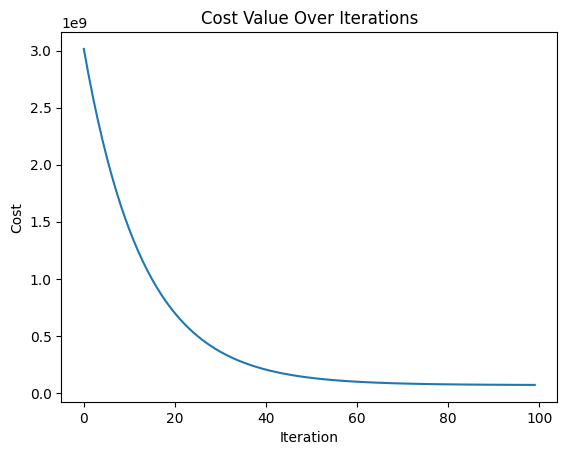

In [158]:
def visualize_over_iterations(cost_history):
  plt.plot(cost_history)
  plt.title("Cost Value Over Iterations")
  plt.xlabel("Iteration")
  plt.ylabel("Cost")
  plt.show()
visualize_over_iterations(J_history)